# SemiTNet — بازتولید، شبیه‌سازی و ارزیابی یکپارچه
این **تنها نوت‌بوک اصلی پروژه** است و کل مسیر را پوشش می‌دهد:
`Environment → Repository → Dataset → Paper-to-Code → Simulation → Results → Tables 1–3 → Figures 1–5 → Reproducibility`.

برای هر خروجی ارزیابی: **هدف، کد، توضیح فارسی، خروجی/مسیر artifact** ارائه می‌شود. مقادیر مقاله «مرجع مقاله» و مقادیر اندازه‌گیری‌شده «اجرای ارزیابی فعلی» هستند؛ هیچ baseline prediction ساخته نمی‌شود.

## 1) محیط و کنترل اجرا
فلگ‌ها: `RUN_SAFE` برای audit/export، `RUN_EVALUATION` برای اجرای ارزیابی، `RUN_HASH` برای SHA کامل و `RUN_FULL_26250` برای full training. پیش‌فرض همه خاموش است.

In [1]:
# هدف: تعیین root و بررسی محیط
# ورودی: محیط Python و repository
# خروجی: نسخه‌ها، GPU، dependencies و Git HEAD
# رفتار مورد انتظار: read-only و بدون نصب خودکار
from pathlib import Path
import os,sys,json,subprocess,hashlib,importlib.util,platform,shlex
import pandas as pd, numpy as np
from PIL import Image as PILImage
from IPython.display import display, Image
ROOT=next((p for p in [Path.cwd().resolve(),*Path.cwd().resolve().parents] if (p/'project.py').is_file() and (p/'reproduction/reference_contract.json').is_file()),None)
if ROOT is None: raise RuntimeError('repository root not found')
os.chdir(ROOT); RUN_SAFE=False; RUN_EVALUATION=False; RUN_HASH=False; RUN_FULL_26250=False
print('ROOT',ROOT); print('Python',sys.version.replace('\n',' ')); print('Platform',platform.platform())
for n in ['torch','numpy','pandas','matplotlib','PIL','yaml','detectron2','pycocotools']: print(n,importlib.util.find_spec(n) is not None)
try:
 import torch; print('PyTorch',torch.__version__,'CUDA',torch.cuda.is_available(),'GPU',torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')
except Exception as e: print(e)
print('HEAD',subprocess.run(['git','rev-parse','HEAD'],text=True,capture_output=True).stdout.strip())

ROOT /Users/hadi/Documents/GitHub/salehi-semiTNet
Python 3.10.19 (main, Dec 17 2025, 20:54:19) [Clang 21.1.4 ]
Platform macOS-26.5.2-arm64-arm-64bit
torch True
numpy True
pandas True
matplotlib True
PIL True
yaml True
detectron2 False
pycocotools True
PyTorch 1.13.1 CUDA False GPU none
HEAD ee86d19951302ee7d48d248ca2f22d6b70147a22


## 2) ساختار مخزن
`scripts/` اجراها، `configs/` تنظیمات، `data/` ورودی، `outputs/` نتایج، `reproduction/` قرارداد علمی، `paper/reference/` مقادیر مرجع و `notebooks/` همین گزارش واحد است.

In [2]:
# هدف: نمایش tree محدود repository
# ورودی: ROOT
# خروجی: مسیرهای مهم تا عمق دو
# رفتار مورد انتظار: dataset بزرگ truncate شود
for n in ['scripts','configs','data','outputs','reproduction','paper','notebooks']:
 b=ROOT/n; print('\n#',n,b.exists())
 if b.exists():
  for p in [x for x in sorted(b.rglob('*')) if len(x.relative_to(b).parts)<=2][:70]: print('  '*(len(p.relative_to(b).parts)-1)+('DIR ' if p.is_dir() else 'FILE ')+p.name)


# scripts True
DIR __pycache__
  FILE download_quick_dataset.cpython-314.pyc
  FILE export_paper_style_figures.cpython-310.pyc
  FILE package_repository_delivery.cpython-310.pyc
  FILE paper_full_dry_run.cpython-310.pyc
  FILE patch_upstream.cpython-310.pyc
  FILE run_quick_real_experiment.cpython-310.pyc
  FILE run_quick_real_experiment.cpython-314.pyc
  FILE run_ted3_compact_evidence.cpython-310.pyc
  FILE run_ted3_compact_evidence.cpython-314.pyc
  FILE validate_ted3_dataset.cpython-310.pyc
FILE acceptance_check.py
FILE bootstrap_upstream.py
FILE compare_to_paper.py
FILE compute_article_metrics.py
FILE download_assets.py
FILE download_paper_assets.py
FILE download_quick_dataset.py
FILE export_client_paper_package.py
FILE export_paper_style_figures.py
FILE generate_final_outputs.py
FILE generate_reference_outputs.py
FILE generate_training_curves.py
FILE inspect_dataset.py
FILE package_client_delivery.py
FILE package_deliverable.py
FILE patch_upstream.py
FILE preflight.py
FILE prepar

## 3) مستندسازی Dataset
مسیرهای authoritative: `data/train/`، `data/test/` و `data/TED3-unlabeled-data-15k-pseudo-mask/`. pseudo-mask بدون provenance برابر human ground truth نیست. SHA overlap فقط با `RUN_HASH=True` اجرا می‌شود.

        role                                      path  exists  files     GiB                              extensions
0      train                                data/train    True  10001   2.888  {'.jpg': 5000, '.png': 5000, '.py': 1}
1       test                                 data/test    True   2450   0.734            {'.jpg': 1225, '.png': 1225}
2  unlabeled  data/TED3-unlabeled-data-15k-pseudo-mask    True  29456  12.098          {'.jpg': 14728, '.png': 14728}


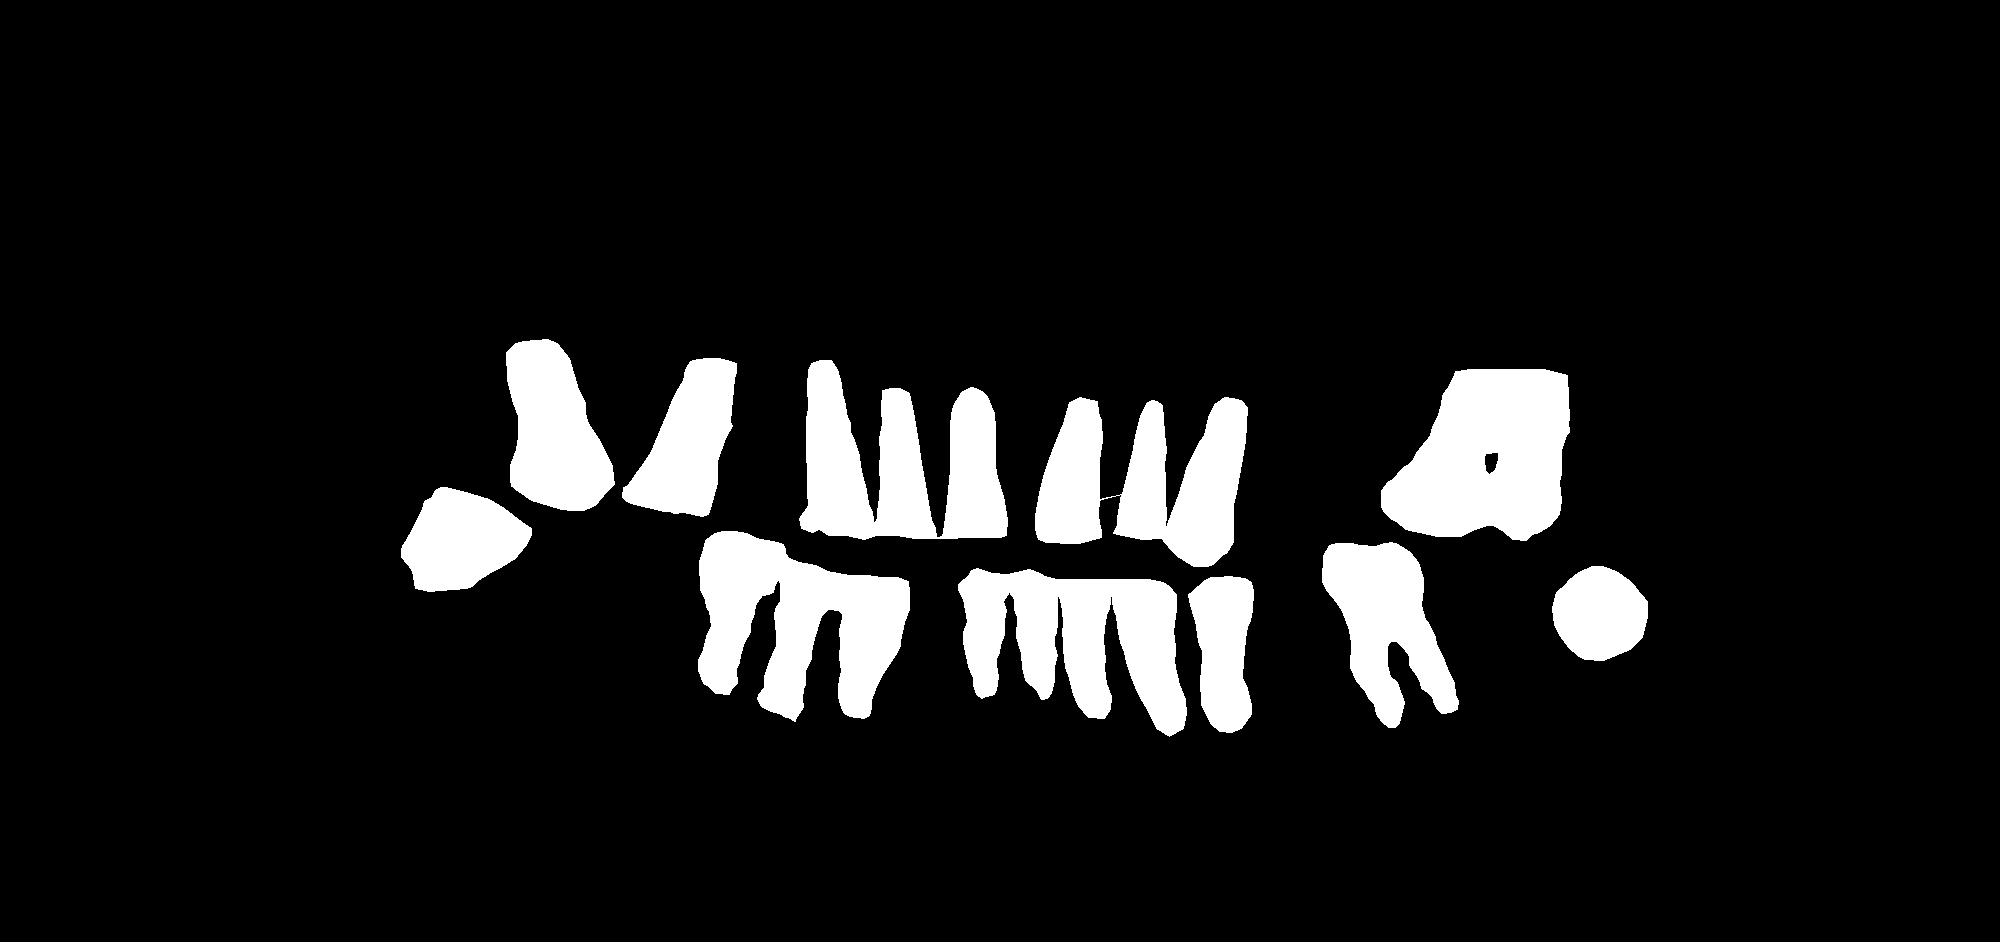

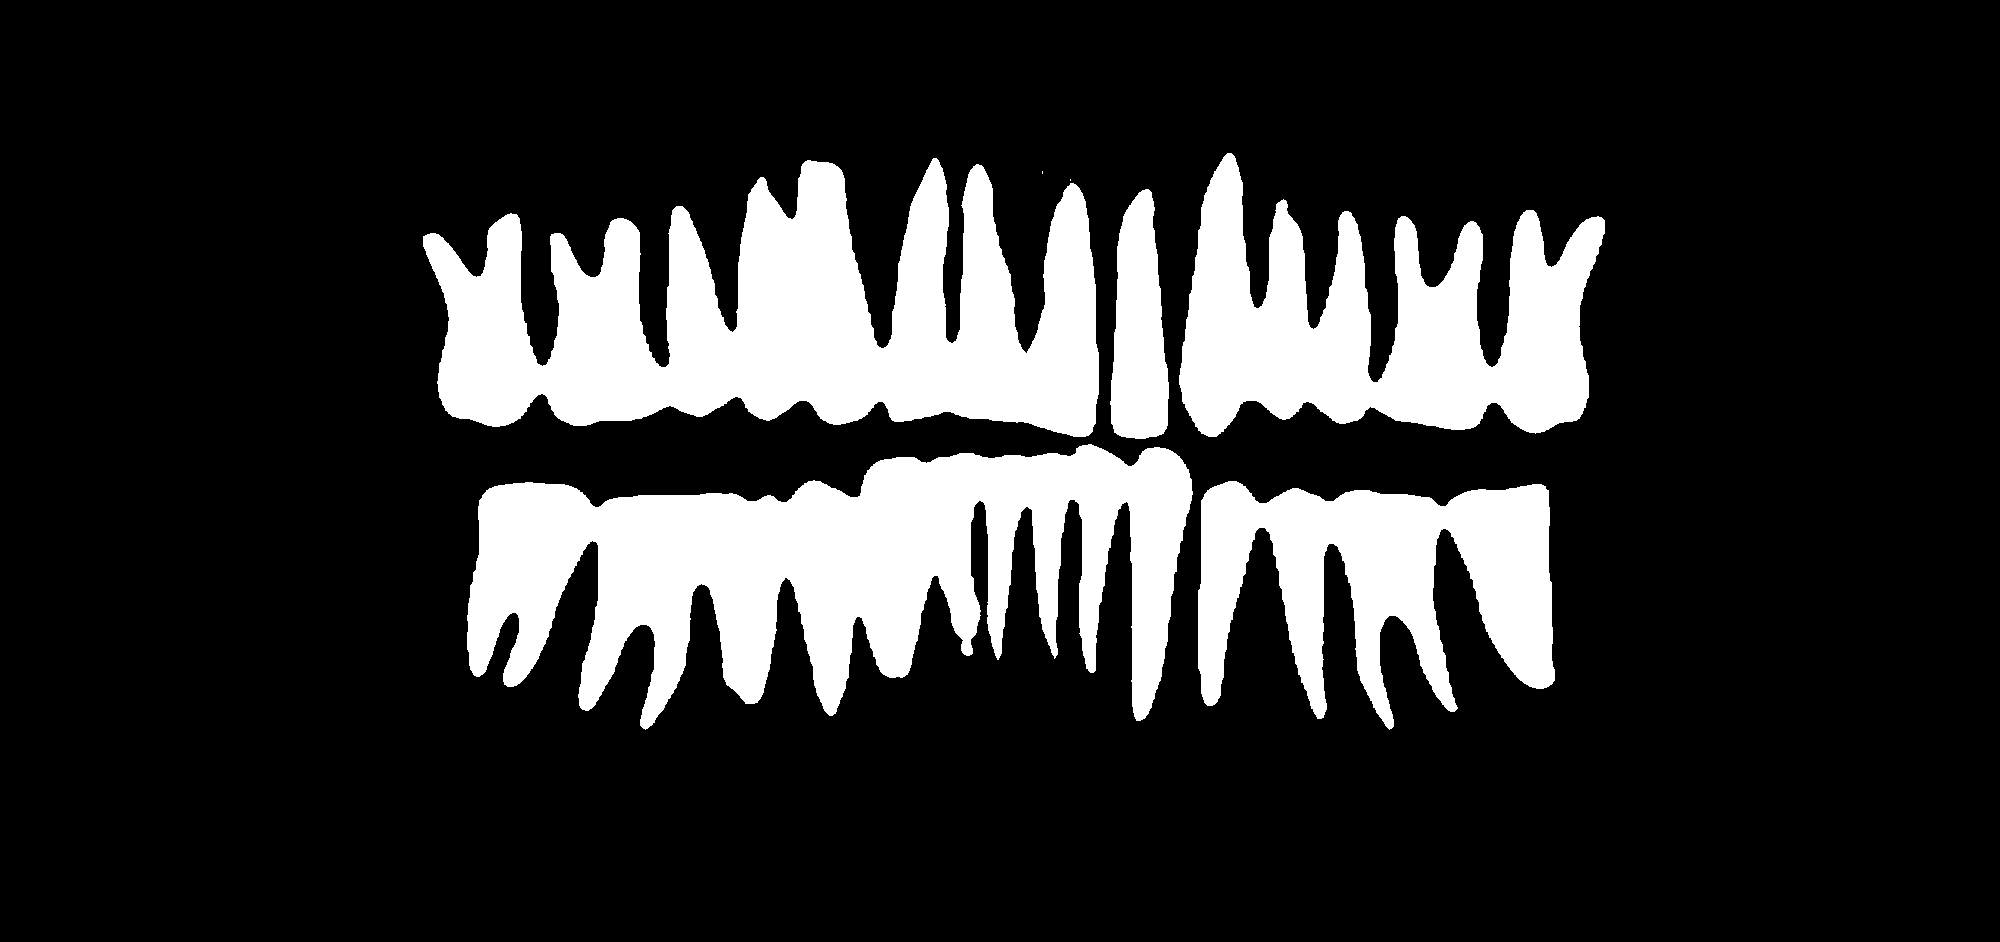

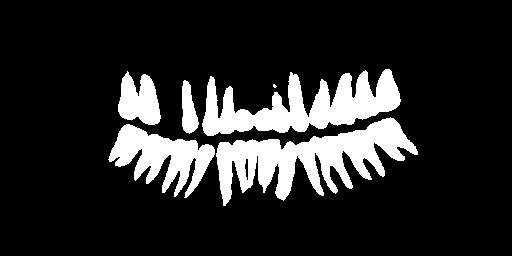

In [3]:
# هدف: inventory dataset و leakage audit اختیاری
# ورودی: train/test/unlabeled
# خروجی: count/size/extensions/sample/manifest/overlap
# رفتار مورد انتظار: read-only؛ hash کامل opt-in
from collections import Counter
D={'train':ROOT/'data/train','test':ROOT/'data/test','unlabeled':ROOT/'data/TED3-unlabeled-data-15k-pseudo-mask'}; EXT={'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}
rows=[]
for r,p in D.items():
 f=[x for x in p.rglob('*') if x.is_file()] if p.is_dir() else []
 rows.append([r,str(p.relative_to(ROOT)),p.is_dir(),len(f),round(sum(x.stat().st_size for x in f)/1024**3,3),dict(Counter(x.suffix.lower() for x in f).most_common(5))])
display(pd.DataFrame(rows,columns=['role','path','exists','files','GiB','extensions']))
for r,p in D.items():
 im=next((x for x in sorted(p.rglob('*')) if x.is_file() and x.suffix.lower() in EXT),None) if p.is_dir() else None
 if im: display(Image(filename=str(im)))
if RUN_HASH:
 def H(x):
  h=hashlib.sha256(); f=x.open('rb')
  for z in iter(lambda:f.read(8*1024*1024),b''): h.update(z)
  f.close(); return h.hexdigest()
 hs={r:{H(x) for x in p.rglob('*') if x.is_file() and x.suffix.lower() in EXT} for r,p in D.items()}
 for a,b in [('train','test'),('train','unlabeled'),('test','unlabeled')]: print(a,b,len(hs[a]&hs[b]))

## 4) نگاشت مقاله به کد
هدف publication: 32 class، 1024 RGB، 100 query، 9 decoder layer، AdamW، LR=1e-4، steps 24000/25000 و 26,250 iteration. evaluator مقاله در `compute_article_metrics.py` و full teacher/student در `run_full.py` است.

In [4]:
# هدف: نمایش config و paper-to-code mapping
# ورودی: reference_contract.json و configs/paper.yaml
# خروجی: جدول اجزای روش و محل پیاده‌سازی
# رفتار مورد انتظار: مسیرهای اجرایی مختلف با هم خلط نشوند
contract=json.loads((ROOT/'reproduction/reference_contract.json').read_text())
try:
 import yaml; cfg=yaml.safe_load((ROOT/'configs/paper.yaml').read_text())
except Exception: cfg={}
display(pd.DataFrame([{'parameter':k,'value':v} for k,v in cfg.items()]))
M=[['Encoder/Backbone','QuickSemiTransformer + full vendor','run_quick_real_experiment.py / vendor'],['Queries/Decoder','100 queries / 9 layers target','configs/paper.yaml + upstream'],['Loss','CE+Dice / upstream losses','supervised_loss + vendor'],['Teacher/Student','pseudo-label + student + EMA','quick script / run_full.py'],['Checkpoint eval','eval-only + COCO metrics','run_official_inference.py'],['Metrics','COCOeval@.5 + Dice/P/R/F1','compute_article_metrics.py'],['Figures/Tables','paper-style exporter','export_paper_style_figures.py']]
display(pd.DataFrame(M,columns=['Component','Implementation','Location']))

                   parameter                                     value
0            upstream_commit  bf66074bee9da9b37fd68454bcbac9140c4f59e2
1                num_classes                                        32
2                 input_size                                      1024
3                num_queries                                       100
4             decoder_layers                                         9
5                  optimizer                                     ADAMW
6                    base_lr                                    0.0001
7                   max_iter                                     26250
8                   lr_steps                            [24000, 25000]
9           total_batch_size                                        16
10                 ema_decay                                    0.9996
11    pseudo_class_threshold                                       0.7
12     pseudo_mask_threshold                                       0.5
13  un

          Component                      Implementation                               Location
0  Encoder/Backbone  QuickSemiTransformer + full vendor  run_quick_real_experiment.py / vendor
1   Queries/Decoder       100 queries / 9 layers target          configs/paper.yaml + upstream
2              Loss           CE+Dice / upstream losses               supervised_loss + vendor
3   Teacher/Student        pseudo-label + student + EMA             quick script / run_full.py
4   Checkpoint eval            eval-only + COCO metrics              run_official_inference.py
5           Metrics           COCOeval@.5 + Dice/P/R/F1             compute_article_metrics.py
6    Figures/Tables                paper-style exporter          export_paper_style_figures.py


## 5) Workflow اجرا
`Data → Teacher → Loss → Pseudo Labels → Student → Ls+Lu → EMA → Evaluation → Tables/Figures`.
دستورات: `project.py ted3-preflight`، `project.py audit`، `run_quick_real_experiment.py`، `export_paper_style_figures.py`، `run_official_inference.py` و برای full training: `run_full.py`.

In [5]:
# هدف: runner کنترل‌شده مراحل simulation/evaluation
# ورودی: RUN_* flags
# خروجی: command status و artifact matrix
# رفتار مورد انتظار: full training فقط opt-in
CMDS={'preflight':[sys.executable,'project.py','ted3-preflight'],'audit':[sys.executable,'project.py','audit'],'evaluation':[sys.executable,'scripts/run_quick_real_experiment.py'],'figures':[sys.executable,'scripts/export_paper_style_figures.py'],'full':[sys.executable,'scripts/run_full.py','--dataset','data/processed/ted3']}
def run(n):
 p=subprocess.run(CMDS[n],text=True,capture_output=True); print(' '.join(map(shlex.quote,CMDS[n])),p.returncode); print(p.stdout[-1800:]); return p.returncode
if RUN_SAFE: run('preflight'); run('audit'); run('figures')
if RUN_EVALUATION: run('evaluation'); run('figures')
if RUN_FULL_26250: run('full')
display(pd.DataFrame([['Preflight','project.py ted3-preflight','outputs/ted3_reproduction'],['Audit','project.py audit','audit/data processed'],['Checkpoint','run_official_inference.py','outputs/inference'],['Training','run_full.py','outputs/full'],['Metrics','compute_article_metrics.py','metrics/tables'],['Exports','export_paper_style_figures.py','outputs/paper_style']],columns=['Phase','Entrypoint','Artifact']))

        Phase                     Entrypoint                   Artifact
0   Preflight      project.py ted3-preflight  outputs/ted3_reproduction
1       Audit               project.py audit       audit/data processed
2  Checkpoint      run_official_inference.py          outputs/inference
3    Training                    run_full.py               outputs/full
4     Metrics     compute_article_metrics.py             metrics/tables
5     Exports  export_paper_style_figures.py        outputs/paper_style


## 6) بارگذاری نتایج موجود
فقط JSON واقعی خوانده می‌شود؛ missing result ساخته نمی‌شود. manifestها برای provenance فهرست می‌شوند.

In [6]:
# هدف: catalog متریک‌ها و manifestها
# ورودی: outputs موجود
# خروجی: metrics_catalog و manifest_catalog
# رفتار مورد انتظار: فقط JSON واقعی
MET=['iou','dice','precision','recall','f1']; rec=[]; mans=[]
for b in [ROOT/'outputs/ted3_reproduction',ROOT/'outputs/paper_reproduction',ROOT/'outputs/inference',ROOT/'outputs/final']:
 if b.exists():
  for p in b.rglob('*.json'):
   try:o=json.loads(p.read_text())
   except:continue
   if isinstance(o,dict) and all(isinstance(o.get(k),(int,float)) for k in MET): rec.append({'source':str(p.relative_to(ROOT)),**{k:float(o[k]) for k in MET}})
   if 'manifest' in p.name.lower(): mans.append([str(p.relative_to(ROOT)),list(o)[:10] if isinstance(o,dict) else []])
display(pd.DataFrame(rec)); display(pd.DataFrame(mans,columns=['manifest','keys']))

                       source        iou       dice  precision     recall         f1
0  outputs/final/metrics.json  33.056516  49.687933  12.526624  12.028957  12.272747


                          manifest                                                                                                                                          keys
0  outputs/final/run_manifest.json  [dataset_manifest, dataset, verified_total_images, seed, model, workflow, split, selected_checkpoint, pseudo_threshold, unsupervised_weight]


# 7) بخش ارزیابی مقاله — Tables 1–3 و Figures 1–5
هر زیر‌بخش شامل توضیح فارسی، کد و artifact است. `PAPER` منبع reference و `FINAL` منبع خروجی اندازه‌گیری‌شده است.

In [7]:
# هدف: آماده‌سازی منابع مشترک بخش ارزیابی
# ورودی: paper/reference و outputs/final
# خروجی: DataFrameها و metrics مورد استفاده در تمام خروجی‌ها
# رفتار مورد انتظار: مرجع مقاله و measured result جدا بمانند
PAPER=ROOT/'paper/reference'; FINAL=ROOT/'outputs/final'; PAPER_STYLE=ROOT/'outputs/paper_style'
table1=pd.read_csv(PAPER/'table1_dataset.csv'); table2=pd.read_csv(PAPER/'table2_overall.csv'); table3=pd.read_csv(PAPER/'table3_groups.csv')
metrics=json.loads((FINAL/'metrics.json').read_text()); history=pd.read_csv(FINAL/'history.csv')
print({k:round(metrics[k],4) for k in MET})

{'iou': 33.0565, 'dice': 49.6879, 'precision': 12.5266, 'recall': 12.029, 'f1': 12.2727}


## 7.1 Table 1 — توزیع داده
**توضیح:** جدول توصیفی dataset از `table1_dataset.csv` خوانده می‌شود و متریک مدل نیست.

     cohort          labeling  training_set  test_set
0  Cohort 1    Labeled images          1398       191
1  Cohort 2  Unlabeled images         14728         0


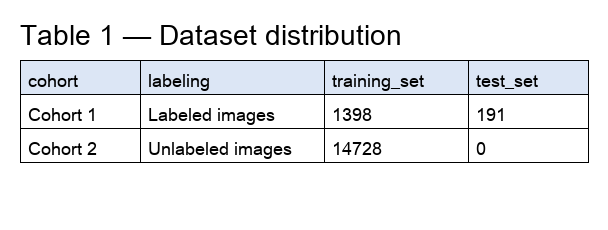

In [8]:
# هدف: نمایش Table 1
# ورودی: table1_dataset.csv
# خروجی: توزیع dataset
# رفتار مورد انتظار: مقادیر مرجع بدون تغییر
display(table1)
display(Image(filename=str(PAPER_STYLE/'tables/table_01_tsi15k_distribution.png')))


![Table 1](../outputs/paper_style/tables/table_01_tsi15k_distribution.png)

## 7.2 Table 2 — عملکرد کلی
**توضیح:** baselineها فقط از مرجع مقاله؛ اجرای فعلی جداگانه با IoU/Dice/Precision/Recall/F1 نمایش داده می‌شود.

         Model    IoU   Dice  Precision  Recall     F1  Params (M)
0   Mask R-CNN  91.58  92.44      92.24   94.13  93.17        44.5
1     MPFormer  93.26  94.39      90.99   93.63  92.29        43.9
2  Mask2Former  94.16  95.43      93.70   96.45  95.06        44.0
3     MaskDINO  93.75  94.64      93.74   95.81  94.76        52.0
4          GEM  93.92  94.75      93.96   96.04  94.99        21.6
5     SemiTNet  94.41  95.45      94.74   97.10  95.90        21.6


                  Run        IOU       DICE  PRECISION     RECALL         F1
0  اجرای ارزیابی فعلی  33.056516  49.687933  12.526624  12.028957  12.272747


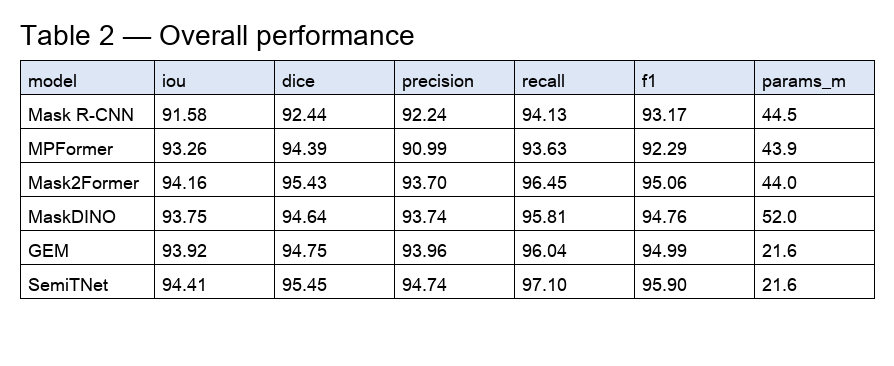

In [9]:
# هدف: نمایش Table 2 و measured metrics جداگانه
# ورودی: table2_overall.csv و metrics.json
# خروجی: reference table + current evaluation row
# رفتار مورد انتظار: عدم نسبت دادن measured numbers به baselineها
display(table2.rename(columns={'model':'Model','iou':'IoU','dice':'Dice','precision':'Precision','recall':'Recall','f1':'F1','params_m':'Params (M)'}))
display(pd.DataFrame([{'Run':'اجرای ارزیابی فعلی',**{k.upper():metrics[k] for k in MET}}]))
display(Image(filename=str(PAPER_STYLE/'tables/table_02_overall_performance.png')))


![Table 2](../outputs/paper_style/tables/table_02_overall_performance.png)

## 7.3 Table 3 — زیرگروه‌ها
**توضیح:** fully dentate و partially edentulous از `table3_groups.csv`. اگر measured subgroup artifact نباشد مقدار جدید ساخته نمی‌شود.

                   Group        Model    IoU   Dice  Precision  Recall     F1
0          fully_dentate   Mask R-CNN  98.84  98.98      99.04   99.36  99.20
1          fully_dentate     MPFormer  99.24  99.32      97.64   97.82  97.73
2          fully_dentate  Mask2Former  99.47  99.59      99.26   99.57  99.41
3          fully_dentate     MaskDINO  99.53  99.64      99.45   99.64  99.55
4          fully_dentate          GEM  99.84  99.86      99.65   99.65  99.65
5          fully_dentate     SemiTNet  99.76  99.78      99.69   99.72  99.70
6   partially_edentulous   Mask R-CNN  89.65  90.70      90.44   92.74  91.57
7   partially_edentulous     MPFormer  91.67  93.09      89.23   92.51  90.84
8   partially_edentulous  Mask2Former  92.24  93.33      92.28   94.82  93.53
9   partially_edentulous     MaskDINO  92.74  94.31      92.18   95.61  93.86
10  partially_edentulous          GEM  92.35  93.39      92.46   95.09  93.76
11  partially_edentulous     SemiTNet  93.00  94.30      93.42  

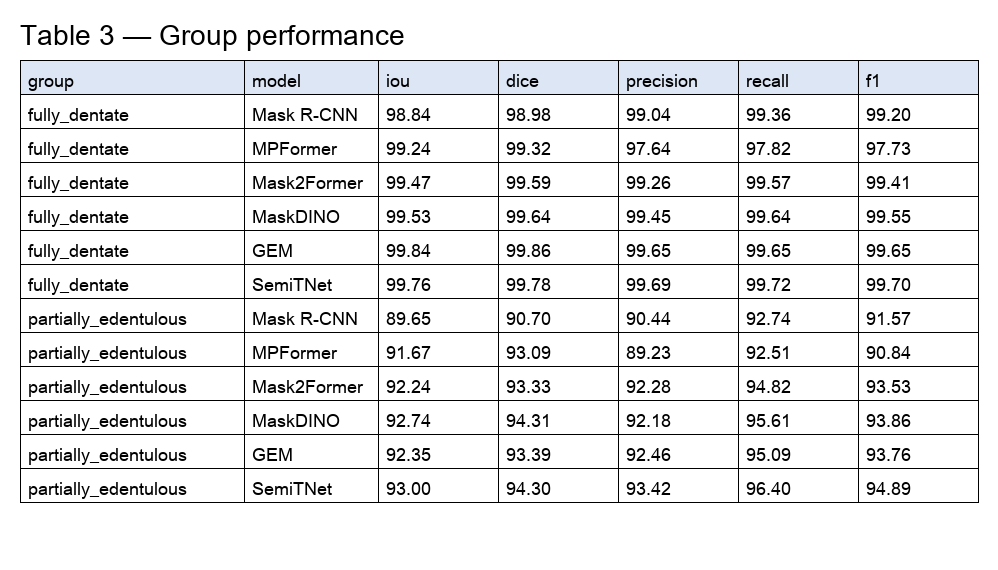

In [10]:
# هدف: نمایش Table 3
# ورودی: table3_groups.csv
# خروجی: group-level reference metrics
# رفتار مورد انتظار: فقط داده موجود
display(table3.rename(columns={'group':'Group','model':'Model','iou':'IoU','dice':'Dice','precision':'Precision','recall':'Recall','f1':'F1'}))
display(Image(filename=str(PAPER_STYLE/'tables/table_03_group_performance.png')))


![Table 3](../outputs/paper_style/tables/table_03_group_performance.png)

## 7.4 Figure 1 — Architecture
**توضیح:** `Panoramic → Encoder → Feature Pyramid → Query Initialization → Mask Decoder → Predictions`؛ تولید توسط `figure1()`.

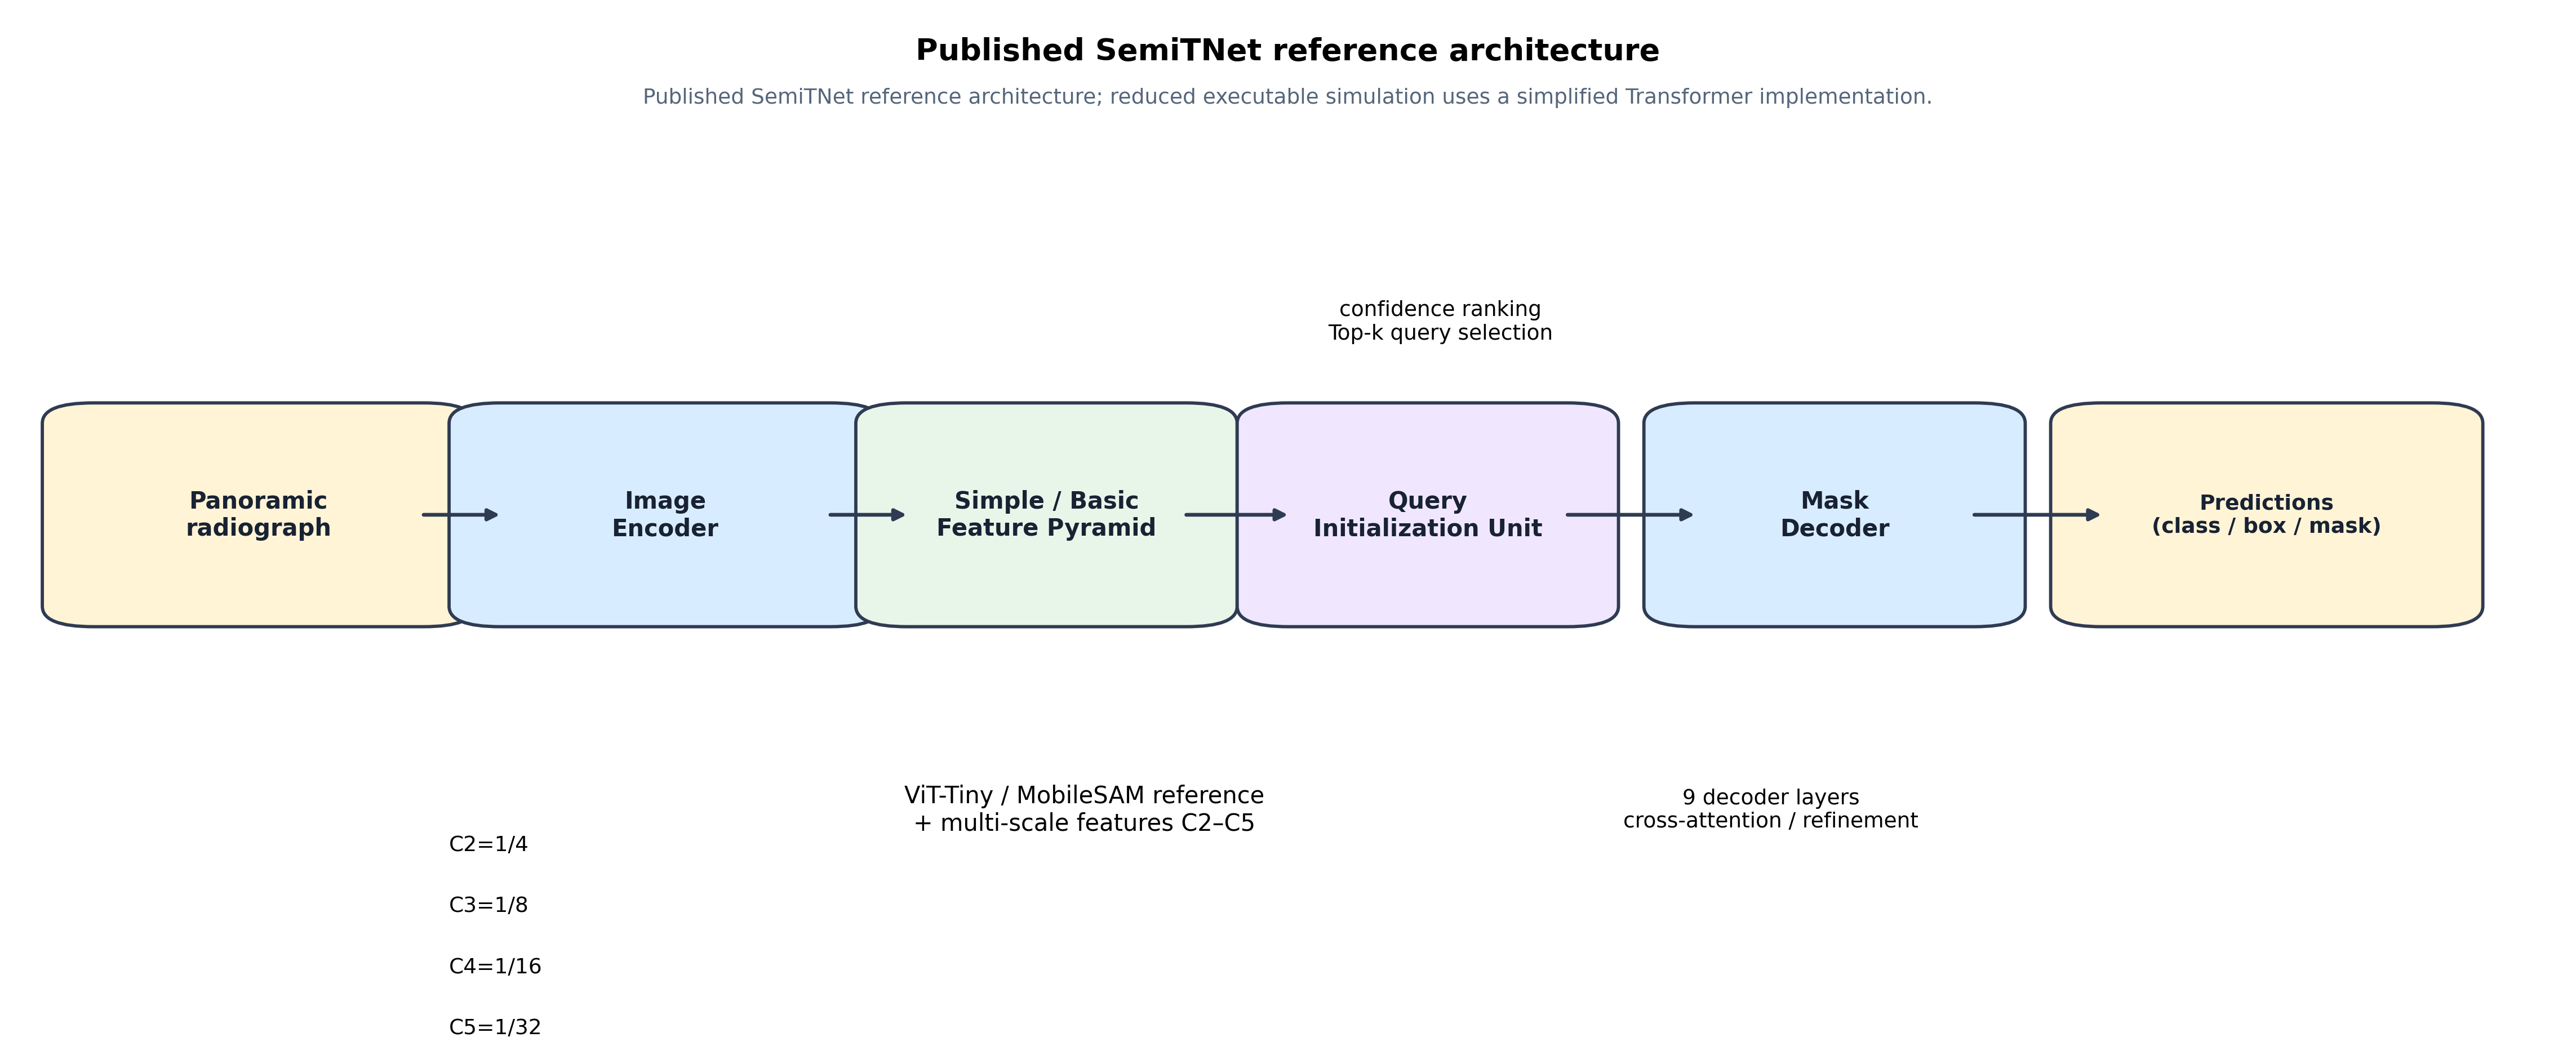

In [11]:
# هدف: نمایش Figure 1
# ورودی: architecture PNG
# خروجی: دیاگرام معماری
# رفتار مورد انتظار: نمایش artifact موجود
p=PAPER_STYLE/'figures/figure_01_semitnet_architecture.png'; display(Image(filename=str(p))) if p.exists() else print('Missing',p)

![Figure 1](../outputs/paper_style/figures/figure_01_semitnet_architecture.png)

## 7.5 Figure 2 — Teacher/Student
**توضیح:** pseudo-label از Teacher، آموزش Student با `Ls+Lu` و به‌روزرسانی EMA؛ تولید توسط `figure2()`.

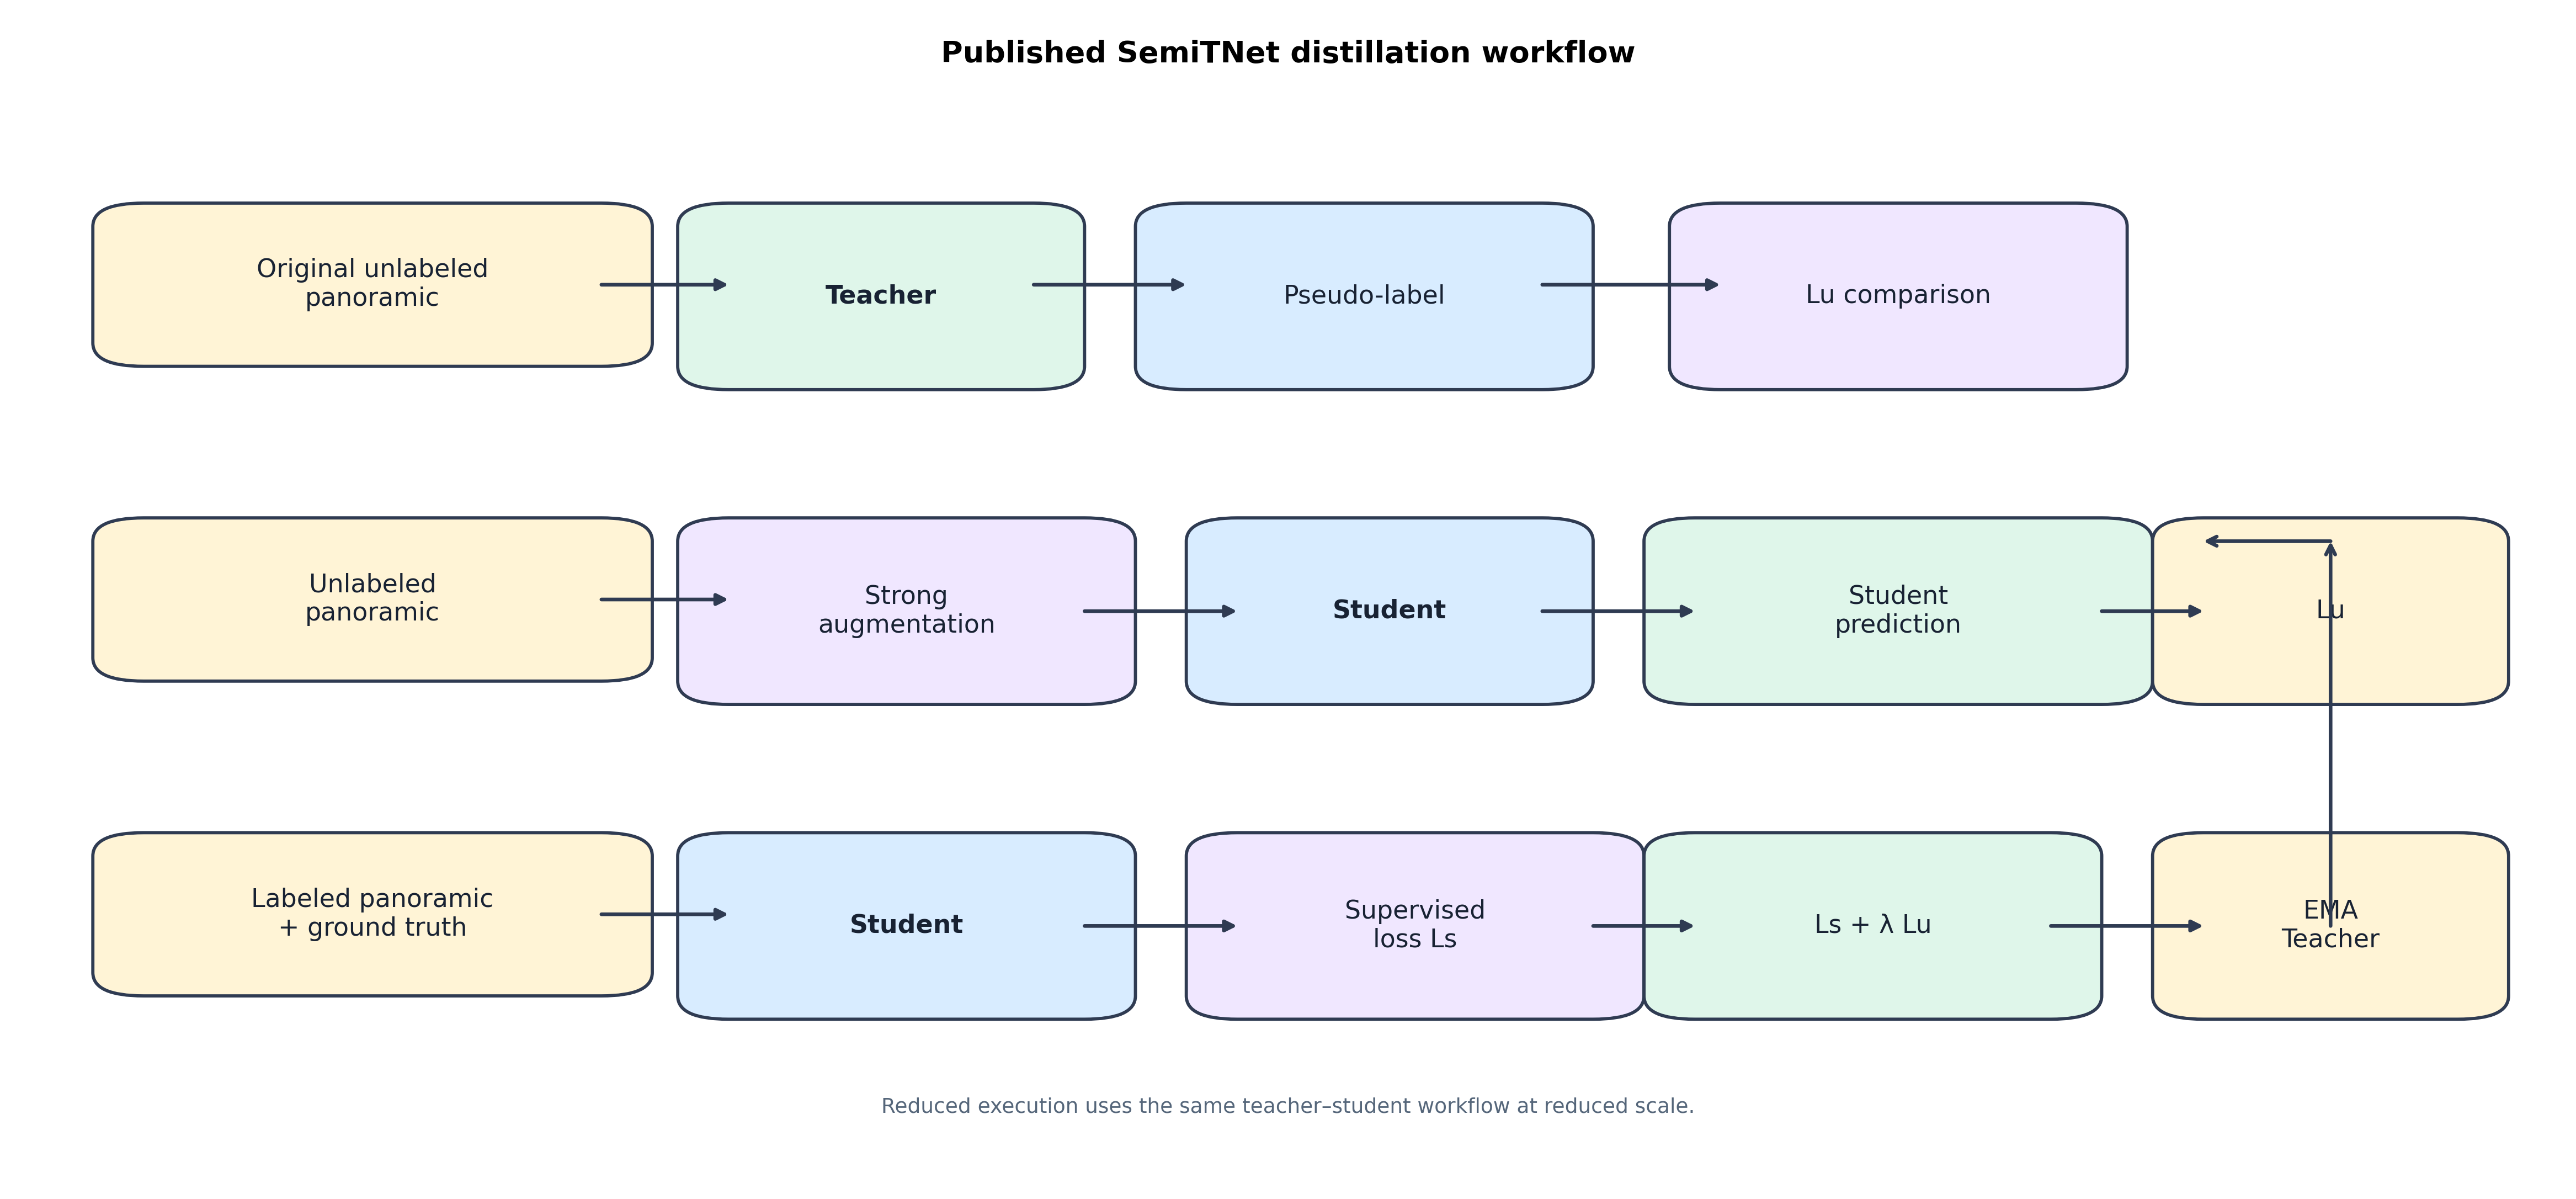

In [12]:
# هدف: نمایش Figure 2
# ورودی: workflow PNG
# خروجی: Teacher/Student/Pseudo-label/EMA diagram
# رفتار مورد انتظار: نمایش artifact موجود
p=PAPER_STYLE/'figures/figure_02_teacher_student_workflow.png'; display(Image(filename=str(p))) if p.exists() else print('Missing',p)

![Figure 2](../outputs/paper_style/figures/figure_02_teacher_student_workflow.png)

## 7.6 Figure 3 — Loss و Precision
**توضیح:** نمودار دو محوره مستقیماً از `history.csv`؛ هیچ نقطه مصنوعی اضافه نمی‌شود.

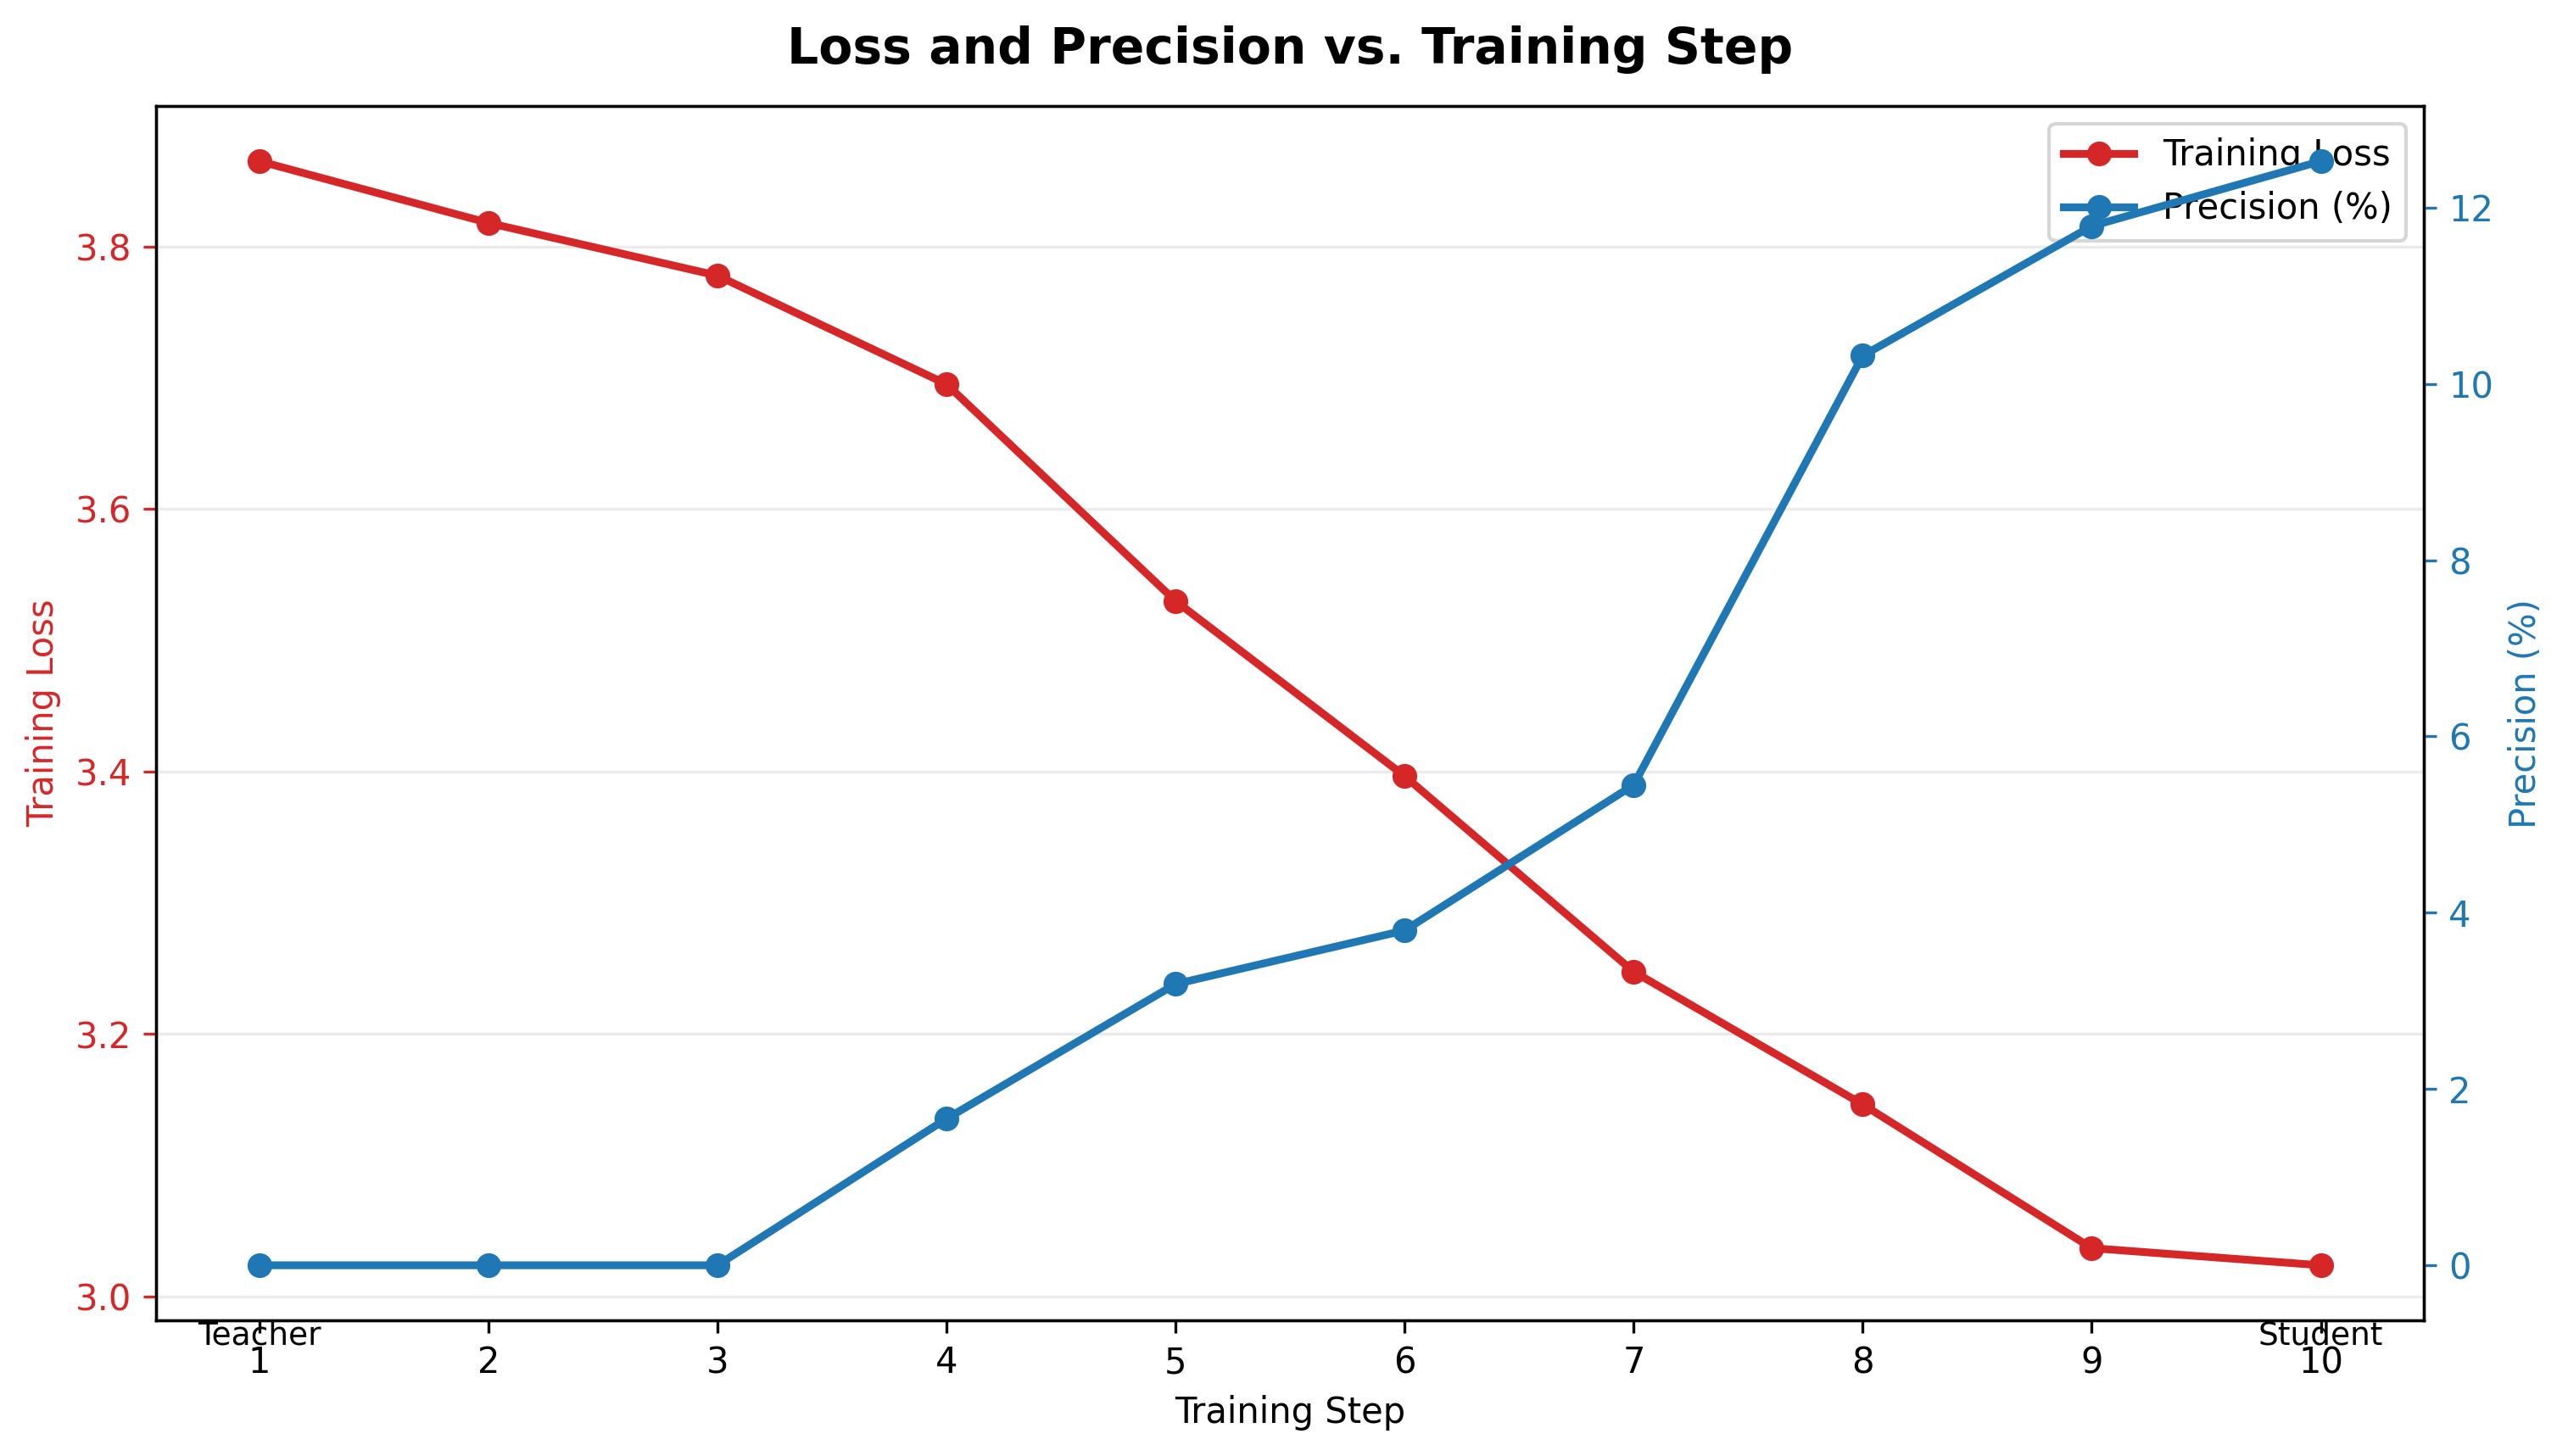

In [13]:
# هدف: بازتولید Figure 3
# ورودی: history.csv
# خروجی: dual-axis Loss/Precision plot
# رفتار مورد انتظار: تمام نقاط از CSV واقعی
display(Image(filename=str(PAPER_STYLE/'figures/figure_03_training_loss_precision.png')))


![Figure 3](../outputs/paper_style/figures/figure_03_training_loss_precision.png)

## 7.7 Figure 4 — Radar متریک‌ها
**توضیح:** پنج محور `IoU, Dice, Precision, Recall, F1`. شکل مرجع paper-style و رادار اجرای فعلی از `metrics.json` جدا هستند.

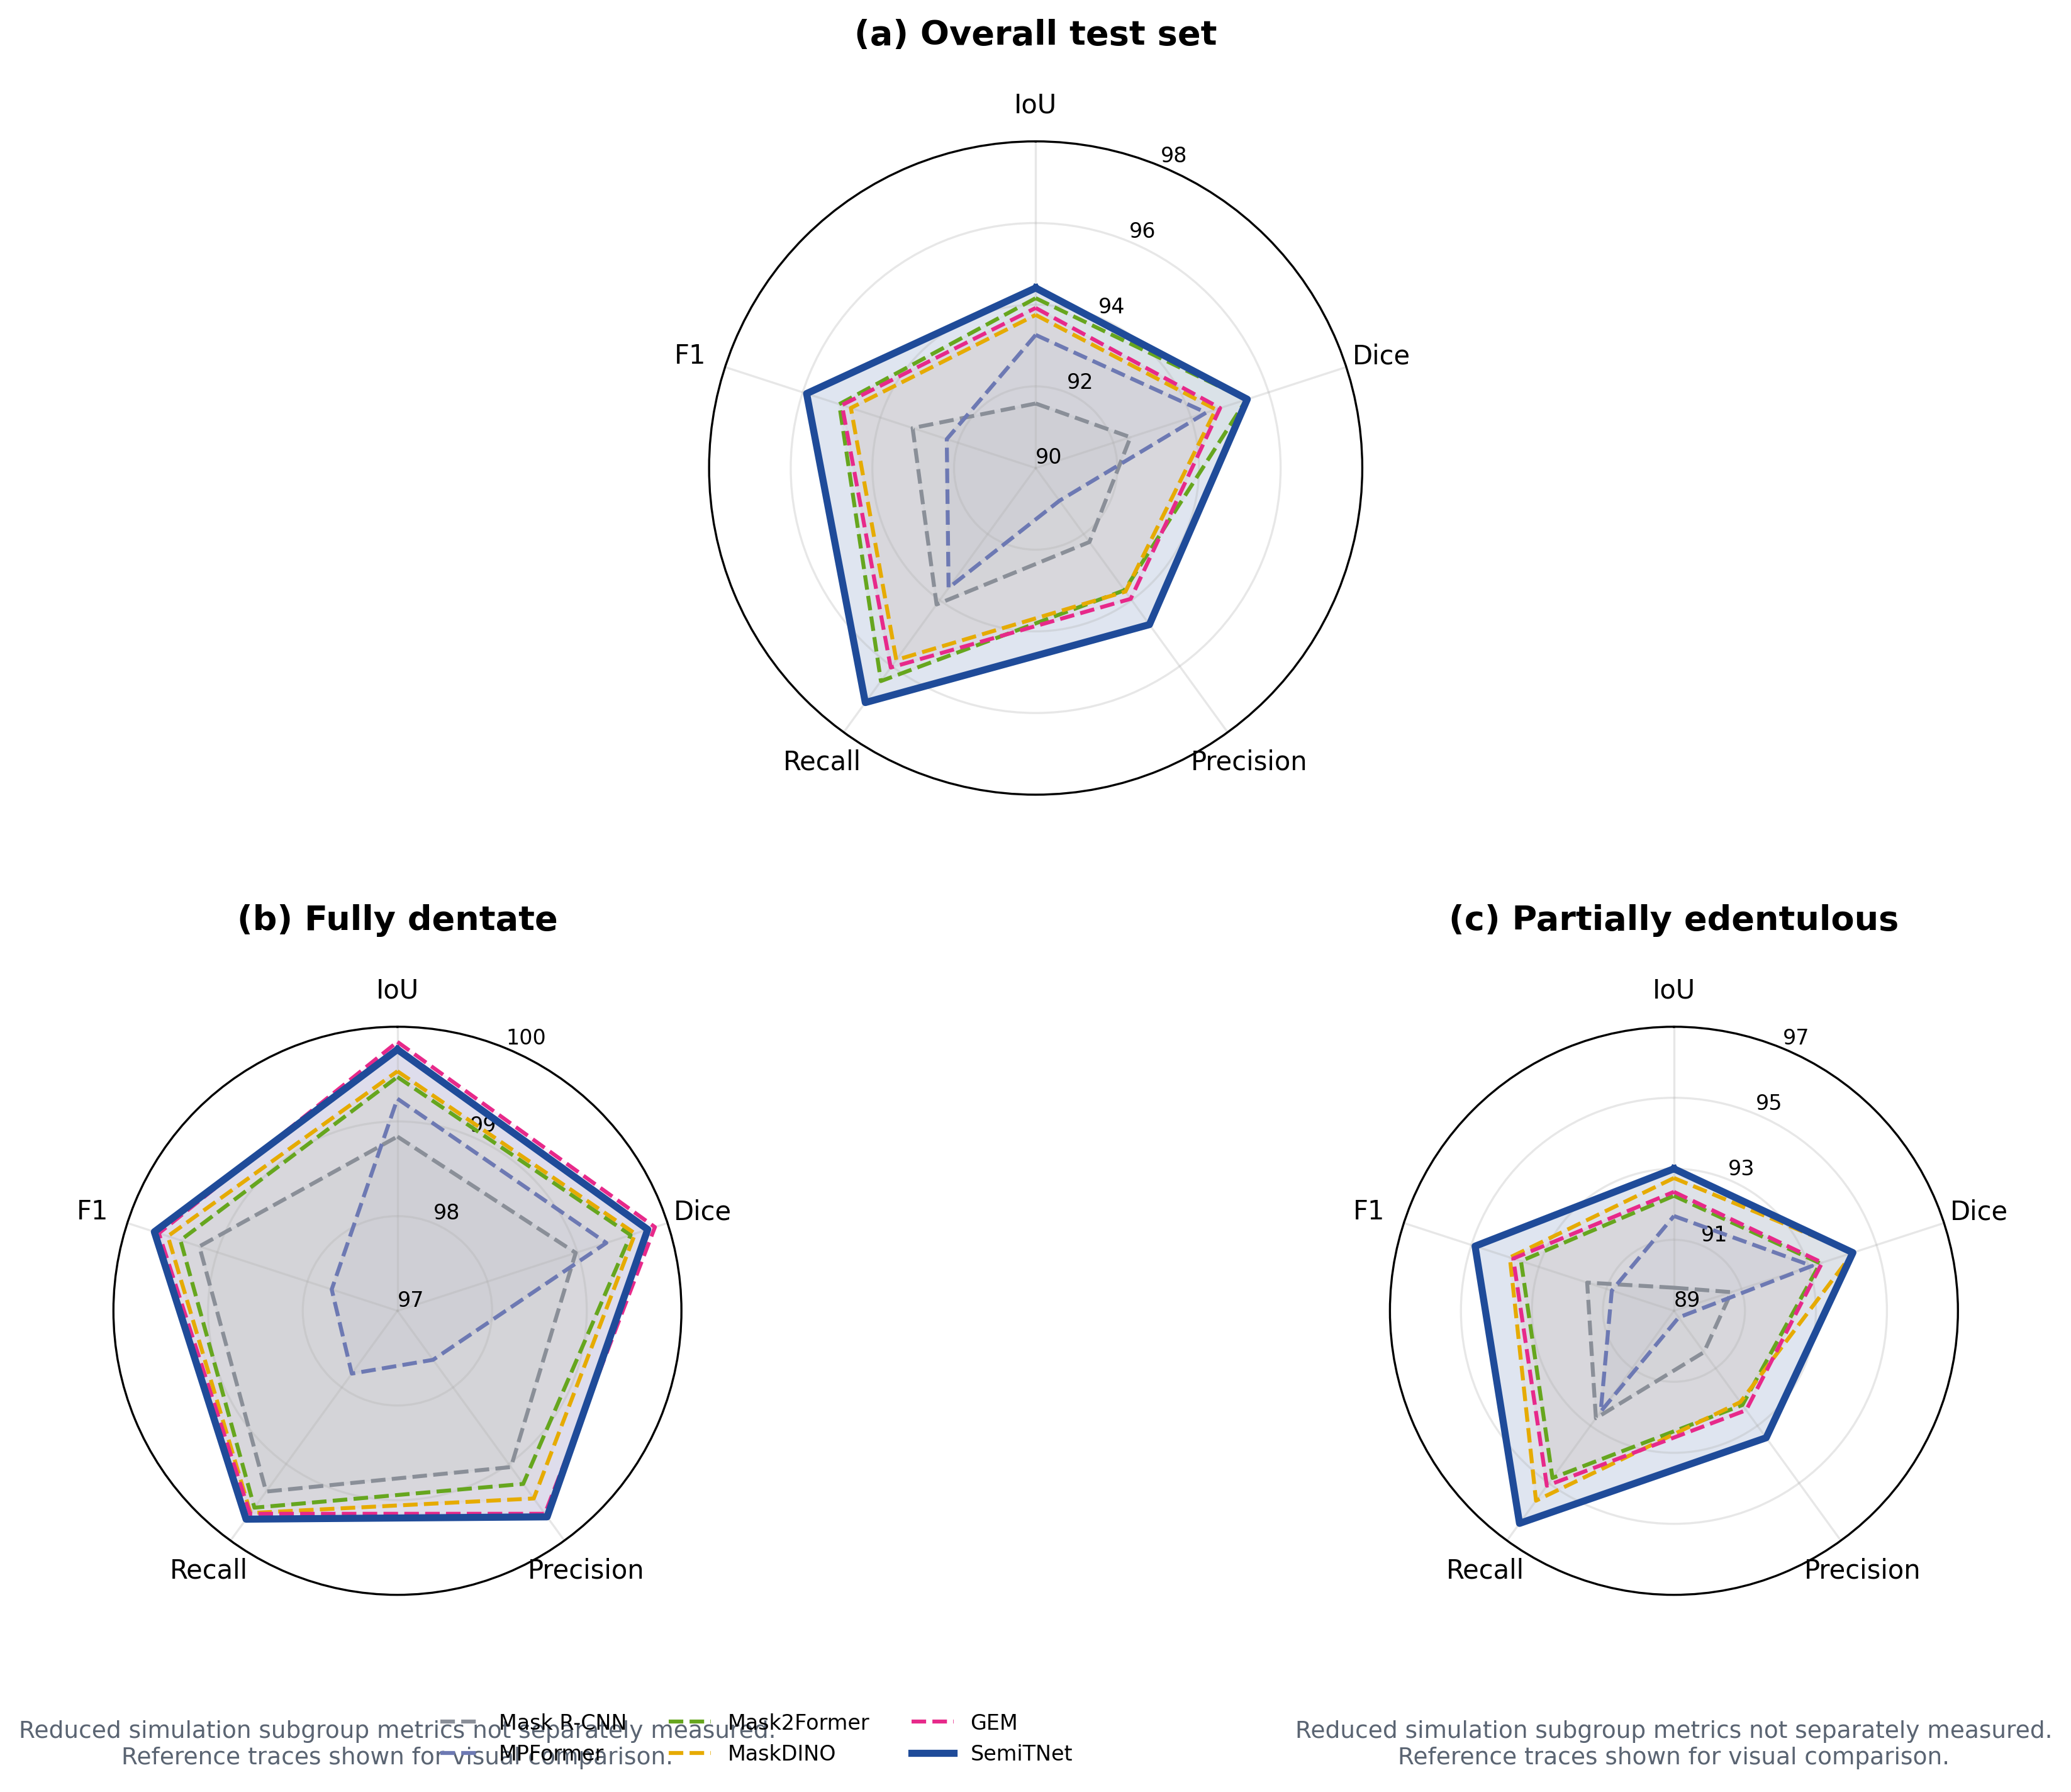

In [14]:
# هدف: ساخت radar اجرای ارزیابی فعلی
# ورودی: metrics.json
# خروجی: radar پنج‌محوره
# رفتار مورد انتظار: فقط متریک‌های اندازه‌گیری‌شده
display(Image(filename=str(PAPER_STYLE/'figures/figure_04_performance_radar.png')))


![Figure 4](../outputs/paper_style/figures/figure_04_performance_radar.png)

## 7.8 Figure 5 — خروجی کیفی واقعی
**توضیح:** فقط artifact واقعی نمایش داده می‌شود. برای Mask R-CNN، MPFormer، Mask2Former، MaskDINO و GEM prediction ساخته/حدس زده نمی‌شود.

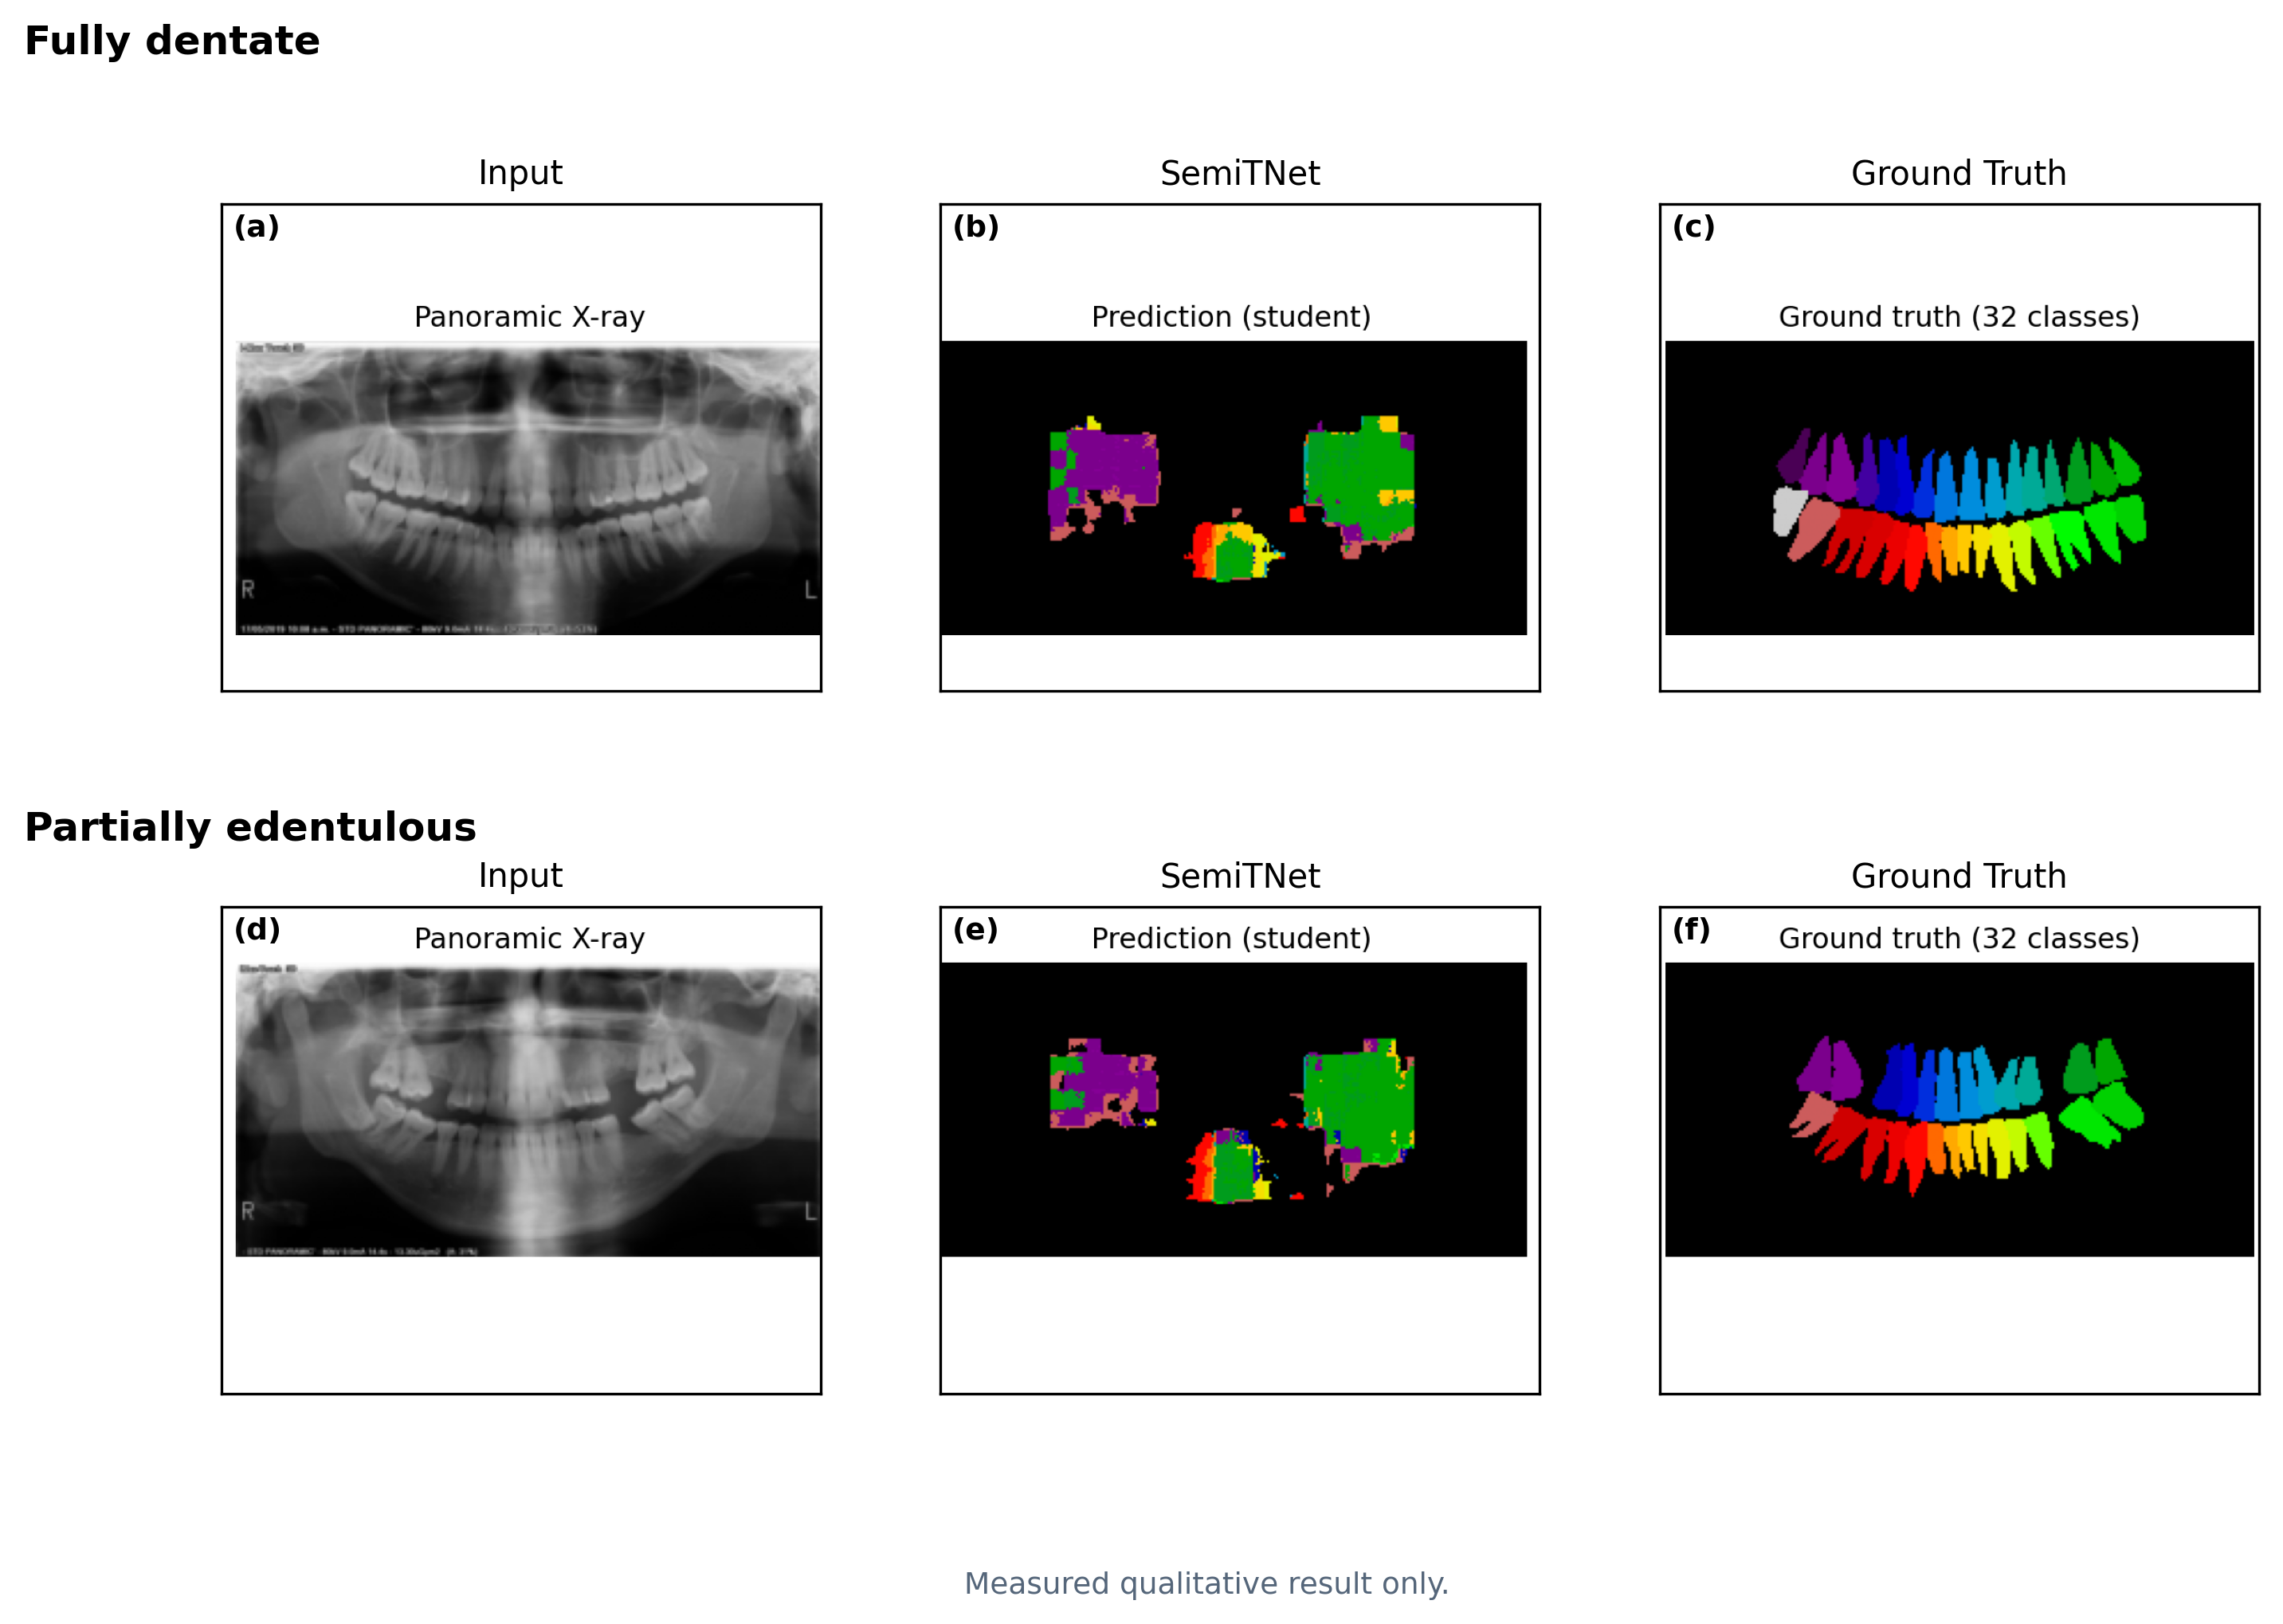

In [15]:
# هدف: نمایش Figure 5 واقعی
# ورودی: measured qualitative artifact یا predictions.png
# خروجی: تصویر کیفی موجود
# رفتار مورد انتظار: عدم ساخت placeholder به‌عنوان نتیجه
q=PAPER_STYLE/'figures/figure_05b_measured_qualitative_only.png'; s=FINAL/'figures/predictions.png'
if q.exists(): display(Image(filename=str(q)))
elif s.exists(): display(Image(filename=str(s)))
else: print('No measured qualitative artifact found')

## 8) مقایسه Paper و Measured
جدول زیر published metrics را کنار artifact اندازه‌گیری‌شده و source آن قرار می‌دهد.

In [16]:
# هدف: Published/Measured/Gap
# ورودی: reference_contract و rec
# خروجی: comparison table
# رفتار مورد انتظار: missing measured خالی
pub=contract['publication']['published_metrics_percent']; prio=['semi_supervised','supervised','checkpoint_eval','outputs/inference','outputs/final']; sel=next((r for t in prio for r in rec if t in r['source']),None)
display(pd.DataFrame([[k.upper(),pub[k],None if not sel else sel[k],None if not sel else sel[k]-pub[k],None if not sel else sel['source']] for k in MET],columns=['Metric','Published SemiTNet','Measured Result','Gap','Source']))

      Metric  Published SemiTNet  Measured Result        Gap                      Source
0        IOU               94.41        33.056516 -61.353484  outputs/final/metrics.json
1       DICE               95.45        49.687933 -45.762067  outputs/final/metrics.json
2  PRECISION               94.74        12.526624 -82.213376  outputs/final/metrics.json
3     RECALL               97.10        12.028957 -85.071043  outputs/final/metrics.json
4         F1               95.90        12.272747 -83.627253  outputs/final/metrics.json


## 9) Reproducibility
دستورات اصلی:
`python project.py ted3-preflight` · `python project.py audit` · `python scripts/run_quick_real_experiment.py` · `python scripts/export_paper_style_figures.py` · `python scripts/validate_final_outputs.py`.
برای full architecture از `run_full.py` و برای checkpoint سازگار از `run_official_inference.py` استفاده می‌شود.

In [17]:
# هدف: نمایش audit و checklist
# ورودی: reproducibility_audit.json، manifests و artifacts
# خروجی: gate status و completeness checklist
# رفتار مورد انتظار: PASS/BLOCKED صریح نمایش داده شوند
a=ROOT/'outputs/reproducibility_audit.json'
if a.exists():
 o=json.loads(a.read_text()); display(pd.DataFrame([[k,v.get('status'),v.get('reason',v.get('allowed_claim',''))] for k,v in o.items() if isinstance(v,dict) and 'status' in v],columns=['Gate','Status','Reason']))
m=FINAL/'run_manifest.json'
if m.exists(): print('Seed',json.loads(m.read_text()).get('seed','not recorded'))
display(pd.DataFrame([['Dataset paths',all(p.exists() for p in D.values())],['Paper config',(ROOT/'configs/paper.yaml').exists()],['Reference contract',(ROOT/'reproduction/reference_contract.json').exists()],['Metrics',(FINAL/'metrics.json').exists()],['History',(FINAL/'history.csv').exists()],['Tables 1–3',all((PAPER/x).exists() for x in ['table1_dataset.csv','table2_overall.csv','table3_groups.csv'])],['Paper-style outputs',PAPER_STYLE.exists()]],columns=['Check','Status']))

                       Gate   Status                                                                   Reason
0       G0_reduced_baseline     PASS                                Reduced-scale measured re-simulation only
1    G1_official_checkpoint  BLOCKED                       Official-checkpoint evaluation outputs are absent.
2    G2_method_faithfulness  BLOCKED  A frozen paper_method_manifest.json has not been produced and verified.
3  G3_training_reproduction  BLOCKED                     No full paper-faithful training outputs are present.


                 Check  Status
0        Dataset paths    True
1         Paper config    True
2   Reference contract    True
3              Metrics    True
4              History    True
5           Tables 1–3    True
6  Paper-style outputs    True


Seed 2024


## 10) جمع‌بندی نهایی
این یک نوت‌بوک واحد، محیط، dataset، paper-to-code، workflow، نتایج، **Tables 1–3، Figures 1–5، توضیح فارسی کد هر خروجی، مقایسه مرجع/اندازه‌گیری‌شده و reproducibility** را پوشش می‌دهد. provenance هر عدد/تصویر حفظ می‌شود و برای مدلی که اجرا نشده prediction ساخته نمی‌شود.